# Exploratory Data Analysis

Feature set: 'data/processed/features.csv'. One row per song: 66 handcrafted features
+ filename (id) + composer (label). This vector is the handcrafted half of the hybrid
model; the piano rolls under 'data/processed/rolls/' are the other half. Feature
definitions live in docs/input-pipeline-design.md.

Goal of this notebook is to decide what is actually ready for modeling:
class balance, missing/degenerate columns, feature distributions & scale, and
collinearity (the histogram families have known exact dependencies) so we can settle
the drop list and scaling before training. Ends with a visual sanity check of the rolls.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("../data/processed/features.csv")
print(df.shape)
df.head()

(1628, 68)


,filename,mi_0,mi_1,mi_2,mi_3,mi_4,mi_5,mi_6,mi_7,mi_8,...,dur_whole,dur_entropy,offbeat_rate,tempo,vel_mean,vel_std,vel_range,vel_flat,vel_track_std,composer
0,042100b_.mid,0.119318,0.295455,0.363636,0.028409,0.022727,0.085227,0.000000,0.068182,0.005682,...,0.022222,1.302049,0.005556,143.000038,96.0,0.0,0,1.0,0.0,bach
1,043100b_.mid,0.041916,0.281437,0.425150,0.029940,0.053892,0.059880,0.005988,0.077844,0.005988,...,0.000000,1.598512,0.035088,189.176471,96.0,0.0,0,1.0,0.0,bach
2,027400b_.mid,0.141243,0.271186,0.384181,0.050847,0.050847,0.039548,0.000000,0.039548,0.000000,...,0.000000,1.469391,0.033149,177.509434,96.0,0.0,0,1.0,0.0,bach
3,Bwv0997 Partita for Lute 1mov.mid,0.023909,0.278586,0.294179,0.069647,0.058212,0.059252,0.032225,0.040541,0.022869,...,0.000000,1.244177,0.346981,160.264901,100.0,0.0,0,1.0,0.0,bach
4,Bwv1066 Orchestral Suite n1 6mov.mid,0.073171,0.242707,0.412721,0.044237,0.021760,0.071019,0.020086,0.043998,0.011478,...,0.002018,1.247362,0.001468,168.042055,76.0,0.0,0,1.0,0.0,bach


## 1. Columns, dtypes, missing values

NaN is expected by design in the features that can fail on edge cases (tempo, key fit,
beat grid); imputation belongs to the modeling pipeline, fit on train only. Anything
else with NaN is a bug.

In [3]:
ID_COL, LABEL_COL = "filename", "composer"
feature_cols = [c for c in df.columns if c not in (ID_COL, LABEL_COL)]

print(f"{len(feature_cols)} feature columns")

print("\nmissing values per column:")
missing = df[feature_cols].isna().sum()
print(missing[missing > 0].to_string() if missing.any() else "none")

66 feature columns

missing values per column:
vi_dissonance    2


Our data has 1,628 songs and 66 feature columns. The only NaNs are 'vi_dissonance' on 2 fully monophonic songs (no simultaneous notes, so no vertical intervals), which is the NaN policy working as intended. Tempo, key fit, and the beat grid never failed on this corpus.

## 2. Class balance

How many songs per composer? Imbalance drives metric choice and whether we stratify the split.

composer
bach         1024
mozart        256
beethoven     212
chopin        136
Name: count, dtype: int64

proportion:
composer
bach         0.629
mozart       0.157
beethoven    0.130
chopin       0.084
Name: count, dtype: float64


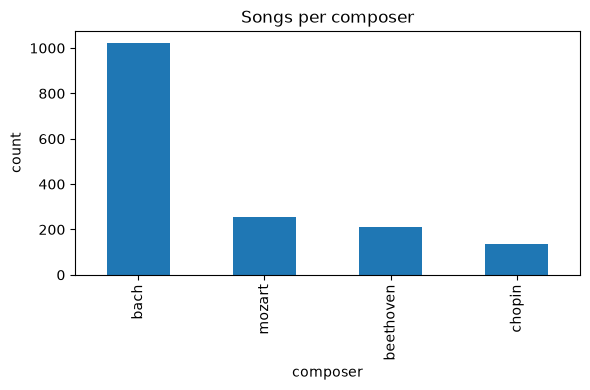

In [4]:
counts = df[LABEL_COL].value_counts()
print(counts)
print("\nproportion:")
print((counts / len(df)).round(3))

ax = counts.plot(kind="bar", figsize=(6, 4))
ax.set_title("Songs per composer")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

**There is an imbalace.** Bach is 63% of songs. We stratify the split by composer, use class weights, and judge by macro-F1 / balanced accuracy rather than accuracy.

## 3. Degenerate columns (constant / near constant)

A feature with one value (or almost one) carries no signal and should be dropped.

In [5]:
nun = df[feature_cols].nunique().sort_values()
constant = nun[nun <= 1].index.tolist()
print("constant columns:", constant or "none")

# near constant: one value covers >99% of rows
near_const = []
for c in feature_cols:
    top_frac = df[c].value_counts(normalize=True).iloc[0]
    if top_frac > 0.99:
        near_const.append((c, round(top_frac, 4)))
print("near constant (>99% one value):", near_const or "none")

nun.head(10)

constant columns: none
near constant (>99% one value): none


vel_flat           2
pitch_max         38
pitch_median      39
pitch_min         41
pitch_range       59
vel_range        116
vel_track_std    788
vel_std          847
vel_mean         860
mi_11            923
dtype: int64

No constant or near constant columns. 'vel_flat' has 2 values because it is a binary flag by design. Every feature varies, so nothing gets dropped on degeneracy grounds.

## 4. Summary statistics & feature scale

Features live on very different scales (histogram shares in [0,1] vs 'tempo' in the
hundreds). This matters for any gradient based model.

In [6]:
desc = df[feature_cols].describe().T[["mean", "std", "min", "max"]]
desc["range"] = desc["max"] - desc["min"]
desc.sort_values("range", ascending=False).head(15)

,mean,std,min,max,range
density_std,36.293340,37.440358,0.816497,296.380108,295.563611
tempo,186.038134,38.488612,52.360524,295.820789,243.460265
vel_range,35.067568,41.535573,0.000000,126.000000,126.000000
vel_mean,83.582276,18.638750,30.812865,127.000000,96.187135
pitch_range,48.919533,11.977762,21.000000,84.000000,63.000000
pitch_min,35.259214,6.372604,9.000000,62.000000,53.000000
note_density,10.875353,7.435646,0.595751,51.308206,50.712455
bass_mean,51.386165,4.553299,31.471920,75.776753,44.304832
pitch_max,84.178747,6.999560,66.000000,107.000000,41.000000
vel_std,6.845817,8.349205,0.000000,40.063986,40.063986


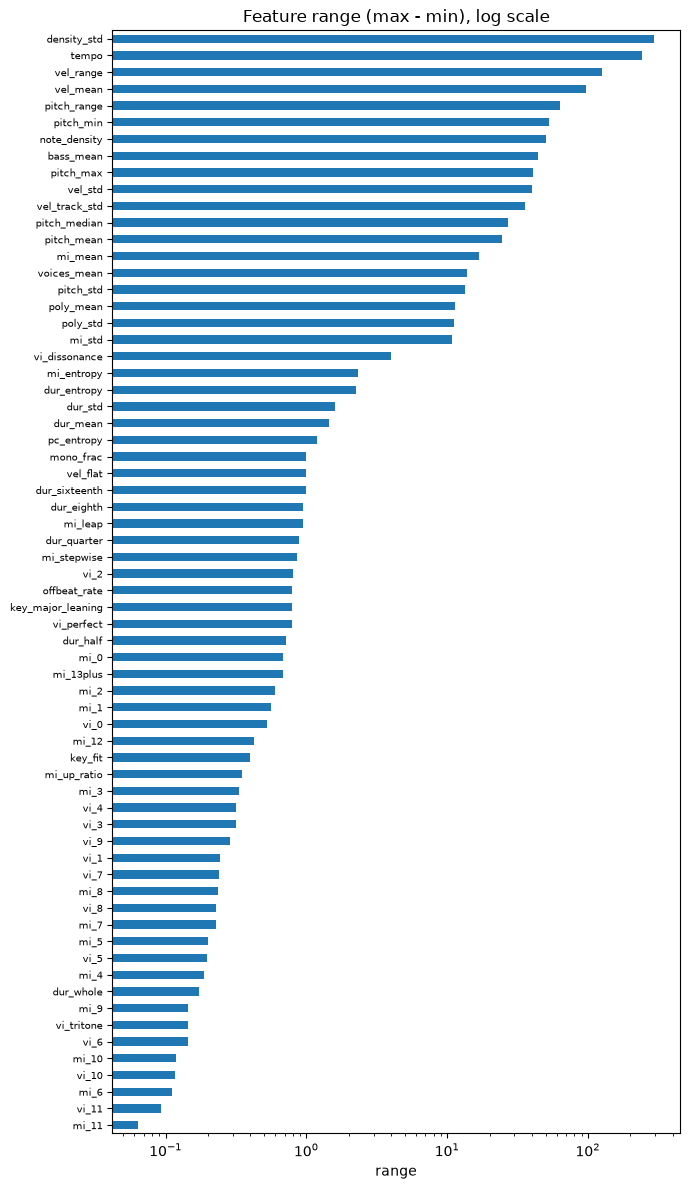

In [7]:
# Visualize scale spread across features (log axis)
ranges = (df[feature_cols].max() - df[feature_cols].min()).sort_values()
ax = ranges.plot(kind="barh", figsize=(7, 12))
ax.set_xscale("log")
ax.set_title("Feature range (max - min), log scale")
ax.set_xlabel("range")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

Wide spread confirms we need scaling: 'density_std' and 'tempo' live in the hundreds while the histogram shares live in [0,1]. Scaling is fit on the train split only, inside the modeling pipeline.

## 5. Distributions

Histograms per feature to spot skew, multimodality, and outliers.

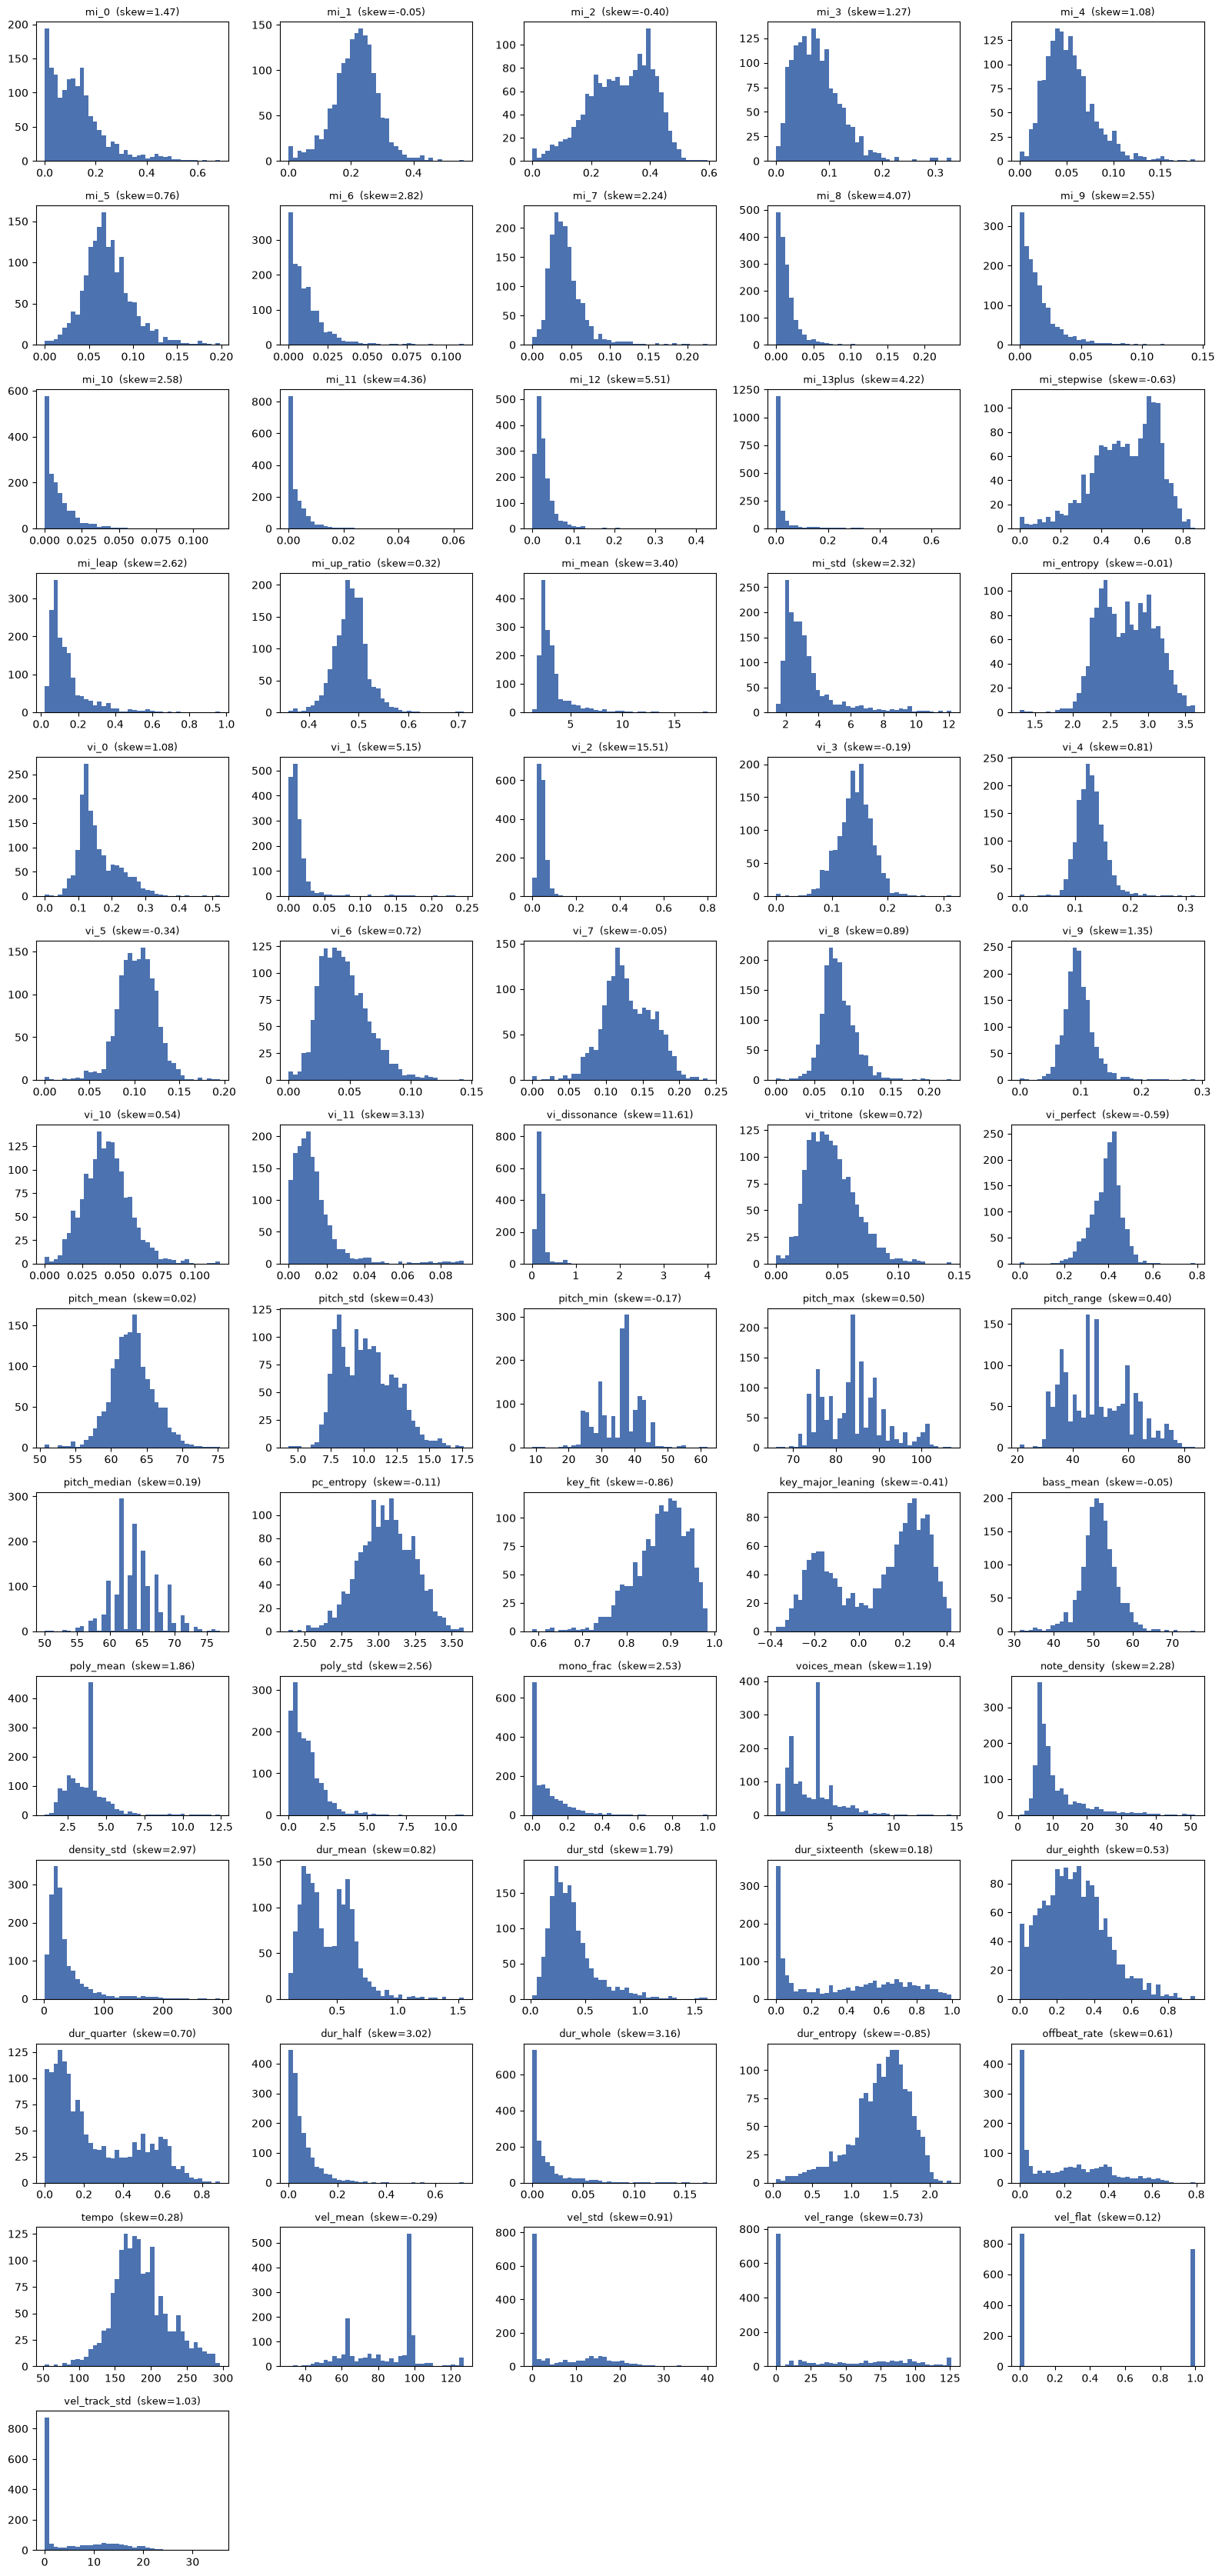

In [8]:
n = len(feature_cols)
ncol = 5
nrow = int(np.ceil(n / ncol))
skew = df[feature_cols].skew()
fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.4 * nrow))
for ax, c in zip(axes.ravel(), feature_cols):
    ax.hist(df[c].dropna(), bins=40, color="#4c72b0")
    ax.set_title(f"{c}  (skew={skew[c]:.2f})", fontsize=9)
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

Most features are well behaved. The exceptions:

- **Heavy right tails**: 'vi_2' (skew 15.5), 'vi_dissonance' (11.6), 'mi_12' (5.5), 'vi_1' (5.2), 'mi_11' and 'mi_13plus' (~4.3). These are shares of rare events, so most songs sit near zero with a long tail. Candidates for PowerTransformer(yeo-johnson) in the pipeline.
- **Mild left skew**: 'key_fit' (-0.86) and 'dur_entropy' (-0.85). No transform needed.
- **Zero inflated velocity**: the flat velocity files put a spike at 0 in 'vel_std', 'vel_range', 'vel_track_std'; the 'vel_flat' flag carries that split explicitly, so scale only.
- Bounded shares (the 'mi_*', 'vi_*', 'dur_*' bins) keep their shape; scale only.

## 6. Correlation & collinearity

The histogram families carry exact dependencies by construction (each histogram sums
to 1, and some ratio features are sums or copies of bins). A dense head consumes this
vector, so we settle the drop list here with correlation pairs and VIF.

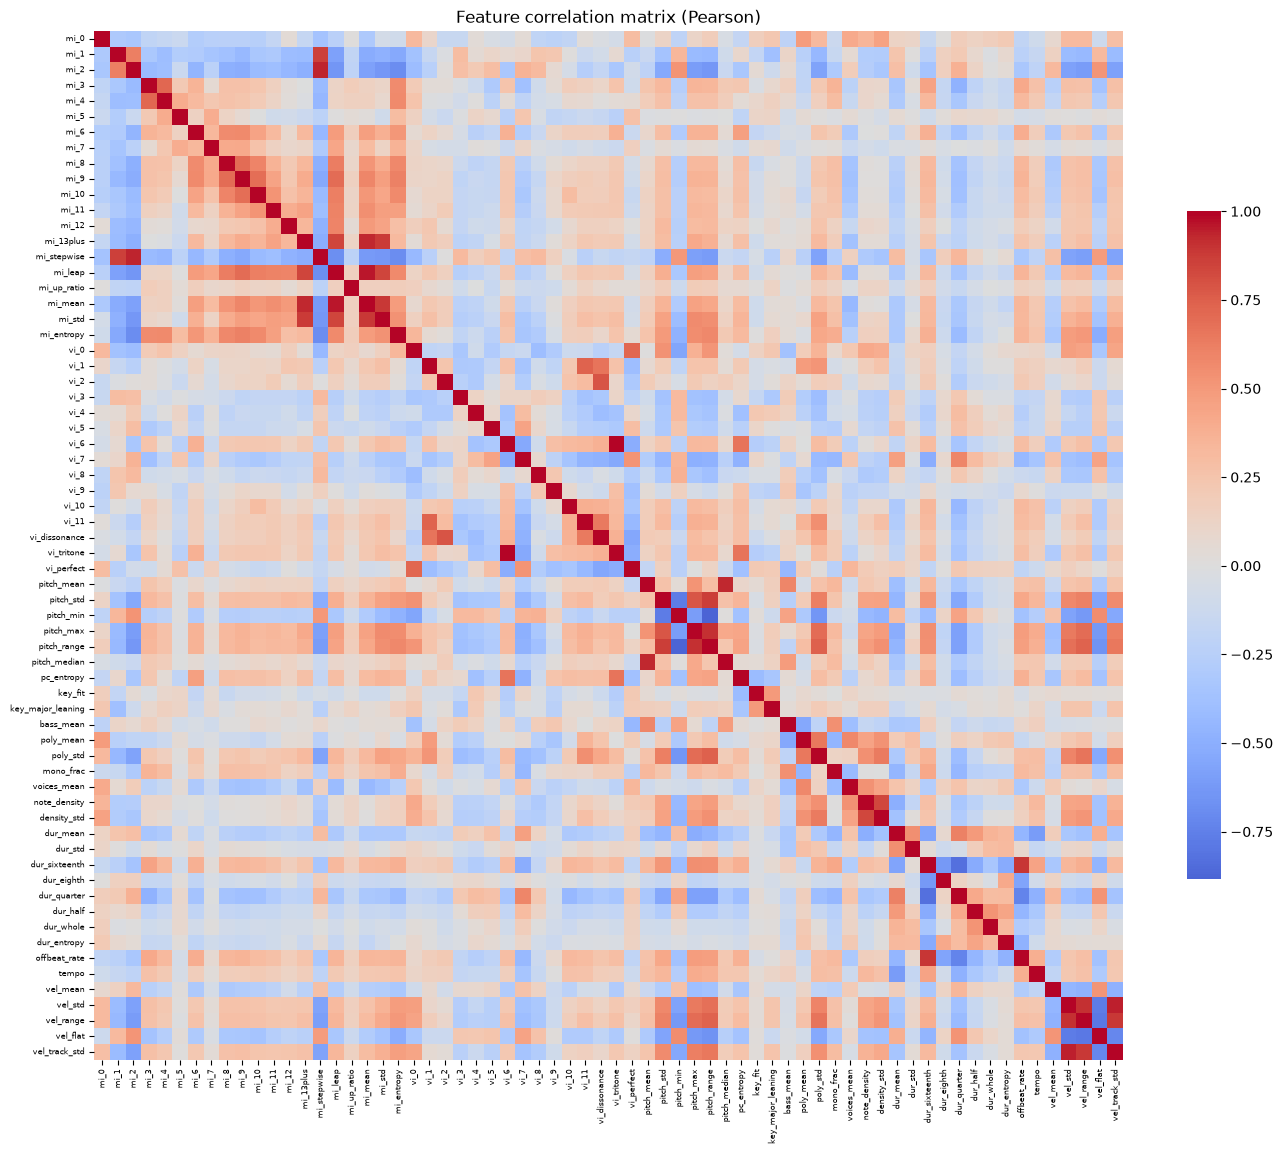

In [9]:
corr = df[feature_cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=True)
plt.tick_params(labelsize=6)
plt.title("Feature correlation matrix (Pearson)")
plt.tight_layout()
plt.show()

In [10]:
# Flag highly correlated pairs
THRESH = 0.85
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feat_a", "level_1": "feat_b", 0: "corr"})
)
high = pairs[pairs["corr"].abs() >= THRESH].sort_values("corr", key=abs, ascending=False)
print(f"pairs with |corr| >= {THRESH}:")
high

pairs with |corr| >= 0.85:


,feat_a,feat_b,corr
1749,vi_6,vi_tritone,1.000000
1007,mi_leap,mi_mean,0.956232
4157,vel_std,vel_track_std,0.942942
146,mi_2,mi_stepwise,0.936901
875,mi_13plus,mi_mean,0.932700
2350,pitch_mean,pitch_median,0.929235
4155,vel_std,vel_range,0.910041
2547,pitch_max,pitch_range,0.905607
3557,dur_sixteenth,offbeat_rate,0.890674
1140,mi_mean,mi_std,0.886723


In [11]:
# Variance Inflation Factor (VIF): multicollinearity, not just pairwise

def vif_table(X):
    X = X.dropna().copy()
    X = (X - X.mean()) / X.std(ddof=0)  # standardize for comparability
    vifs = {}
    for c in X.columns:
        others = X.drop(columns=c)
        r2 = LinearRegression().fit(others, X[c]).score(others, X[c])
        vifs[c] = np.inf if r2 >= 1 else 1.0 / (1.0 - r2)
    return pd.Series(vifs).sort_values(ascending=False)

vif = vif_table(df[feature_cols])
print("VIF > 10 indicates problematic multicollinearity:")
vif.head(25)

VIF > 10 indicates problematic multicollinearity:


mi_0             inf
mi_1             inf
vi_4             inf
vi_5             inf
vi_6             inf
vi_7             inf
vi_8             inf
vi_9             inf
vi_10            inf
vi_11            inf
vi_perfect       inf
vi_2             inf
pitch_min        inf
pitch_max        inf
pitch_range      inf
dur_sixteenth    inf
dur_eighth       inf
dur_quarter      inf
dur_half         inf
dur_whole        inf
vi_3             inf
vi_tritone       inf
vi_1             inf
vi_0             inf
mi_6             inf
dtype: float64

The exact dependencies are all confirmed by construction and by infinite VIF: each histogram family sums to 1 ('mi_*' 14 bins, 'vi_*' 12 bins, 'dur_*' 5 bins), 'mi_stepwise' = 'mi_1' + 'mi_2', 'mi_leap' = sum of 'mi_7'..'mi_13plus', 'vi_perfect' = 'vi_0' + 'vi_5' + 'vi_7', 'vi_tritone' is a copy of 'vi_6', and 'pitch_range' = 'pitch_max' - 'pitch_min'.

**Drop list for the modeling pipeline (8): 'mi_stepwise', 'mi_leap', 'mi_11', 'vi_tritone', 'vi_perfect', 'vi_11', 'dur_whole', 'pitch_range'.** That leaves 58 features with no exact dependency (max VIF falls from inf to ~860). The residual inflation is the histogram summary stats ('mi_mean', 'mi_std', 'mi_entropy') sharing information with their own bins, which is by construction and tolerable for the nets; revisit only if training is unstable. The CSV stays raw; the drop happens in the pipeline.

## 7. Do features separate the composers?

Standardized per class means: which features actually differ across composers
(i.e. carry signal for classification)?

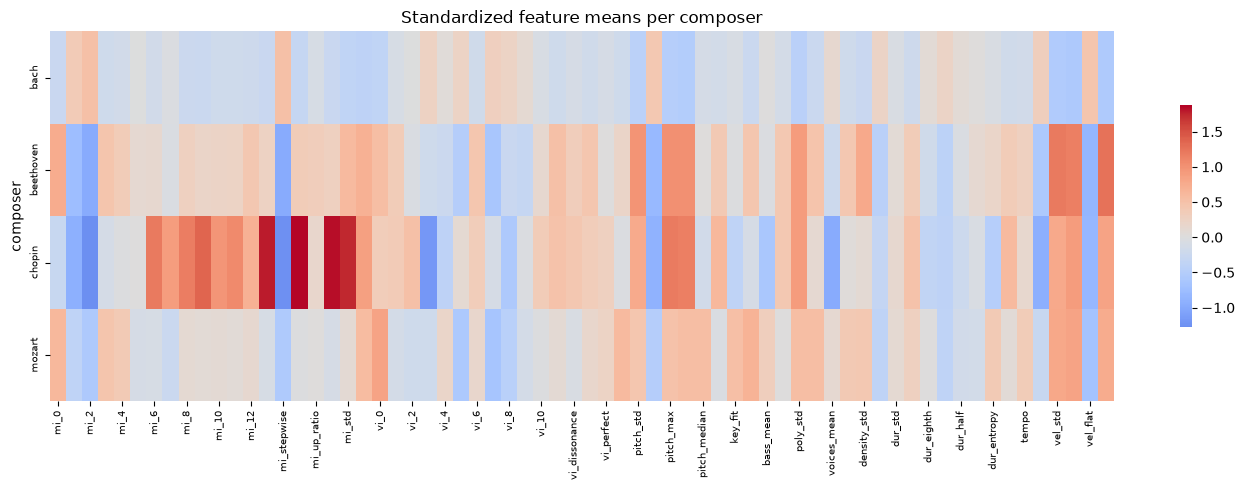

mi_leap          0.973768
mi_mean          0.958540
mi_13plus        0.930383
mi_std           0.912078
vel_track_std    0.791748
vel_range        0.786017
mi_2             0.783914
mi_stepwise      0.774373
vel_std          0.765073
pitch_range      0.757013
pitch_max        0.756280
mi_9             0.701764
poly_std         0.644100
mi_6             0.632918
vel_flat         0.630887
dtype: float64

In [12]:
z = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std(ddof=0)
z[LABEL_COL] = df[LABEL_COL]
class_means = z.groupby(LABEL_COL)[feature_cols].mean()

plt.figure(figsize=(14, 5))
sns.heatmap(class_means, cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.6})
plt.tick_params(labelsize=7)
plt.title("Standardized feature means per composer")
plt.tight_layout()
plt.show()

# Rank features by how much their class means spread (proxy for discriminative power)
class_means.std().sort_values(ascending=False).head(15)

The strongest separators are the melodic interval features, exactly what the research promised (and what the old summary feature set lacked entirely). 'mi_leap', 'mi_mean', and 'mi_13plus' top the ranking, driven by **Chopin sitting 1.8 to 1.9 std above the mean on leap size**. **Bach is the mirror image**: more stepwise motion ('mi_2' +0.52), flat velocity ('vel_flat' +0.46), narrow range. **Beethoven owns the dynamics**: 'vel_track_std' +1.27 with the widest 'poly_std'. 'vi_dissonance' orders the composers by era (bach -0.11, mozart -0.06, beethoven +0.32, chopin +0.43), a nice sanity check against music history.

Mozart is mild on almost every feature, so I'd expect Beethoven vs Mozart (and some Mozart vs Bach) confusion from this vector alone; pulling those apart is the roll branch's job.

## 8. Roll sanity check

Load a few rolls from the manifest and render the frame channel: pitch on the vertical,
time on the horizontal. If these don't look like music, the CNN input is broken.

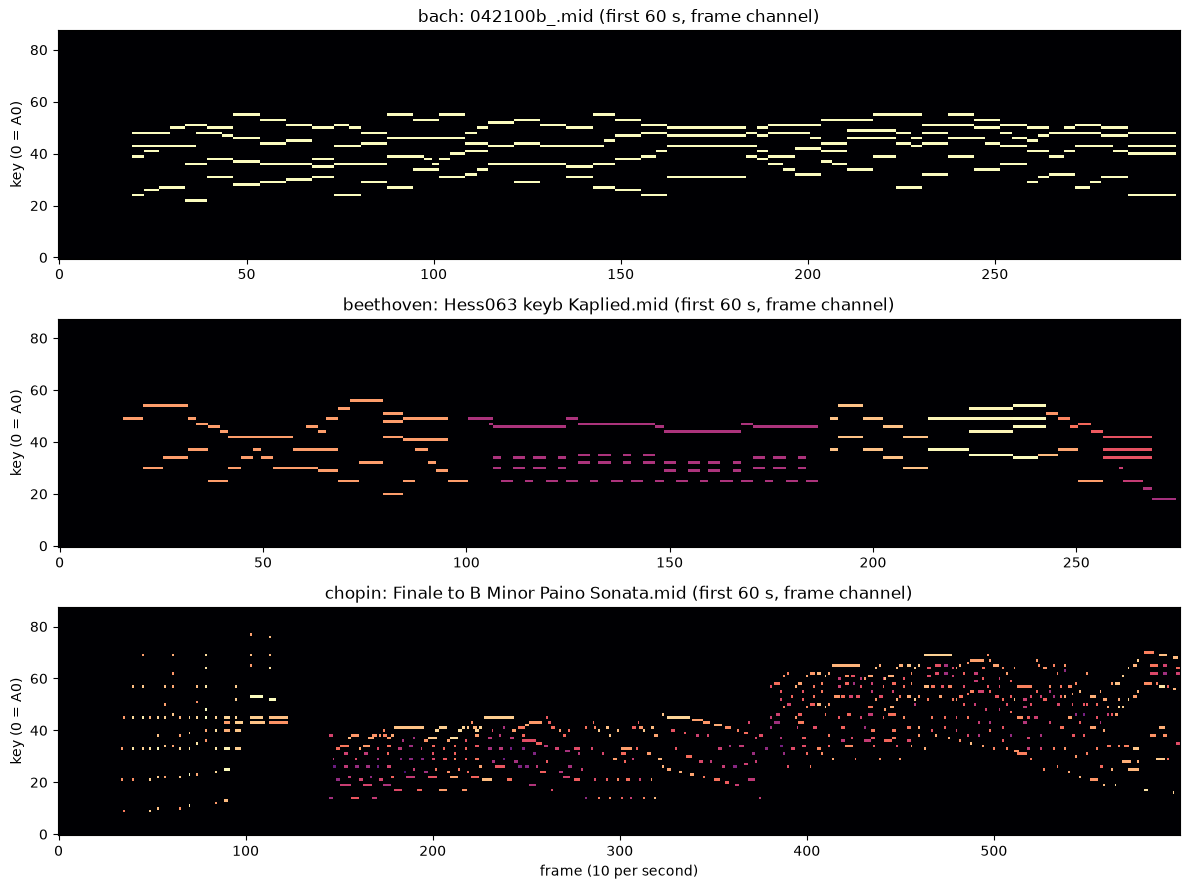

            count    mean     std    min     25%     50%     75%      max
composer                                                                 
bach       1024.0  1562.0  2450.0  175.0   425.0   768.0  1895.0  52094.0
beethoven   212.0  5085.0  4925.0  219.0  2106.0  3974.0  6714.0  50324.0
chopin      136.0  2209.0  1845.0  234.0   927.0  1576.0  3122.0  13528.0
mozart      256.0  4009.0  2731.0  261.0  2070.0  3478.0  5296.0  14782.0


In [13]:
manifest = pd.read_csv("../data/processed/rolls_manifest.csv")
picks = manifest.groupby("composer").first().reset_index().iloc[:3]

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
for ax, (_, row) in zip(axes, picks.iterrows()):
    arr = np.load("../" + row["path"])["roll"]
    ax.imshow(arr[1, :, :600], aspect="auto", origin="lower", cmap="magma",
              interpolation="nearest")
    ax.set_title(f"{row['composer']}: {row['filename']} (first 60 s, frame channel)")
    ax.set_ylabel("key (0 = A0)")
axes[-1].set_xlabel("frame (10 per second)")
plt.tight_layout()
plt.show()

print(manifest.groupby("composer")["n_frames"].describe().round(0))

In [14]:
# Crop coverage: the training loader takes random 30 second crops (300 frames)
CROP = 300
short = manifest[manifest["n_frames"] < CROP]
print(f"songs shorter than one crop: {len(short)} of {len(manifest)}")
print(short.groupby("composer").size().to_string())
print(f"shortest song: {manifest['n_frames'].min()} frames")

total = manifest.groupby("composer")["n_frames"].sum()
print("\nshare of songs vs share of frames:")
print(pd.DataFrame({
    "songs": manifest["composer"].value_counts(normalize=True).round(3),
    "frames": (total / total.sum()).round(3),
}).to_string())

# pitch clipping into the 88 key roll (from the feature table)
print(f"\nsongs with notes below key 21: {(df['pitch_min'] < 21).sum()}, "
      f"above key 108: {(df['pitch_max'] > 108).sum()}")

songs shorter than one crop: 70 of 1628
composer
bach         63
beethoven     4
chopin        2
mozart        1
shortest song: 175 frames

share of songs vs share of frames:
           songs  frames
composer                
bach       0.629   0.400
beethoven  0.130   0.269
chopin     0.084   0.075
mozart     0.157   0.256

songs with notes below key 21: 11, above key 108: 0


The rolls read as music: the Bach chorale is a sustained four voice texture in a tight register with uniform color (flat velocity), the Beethoven song has phrase level dynamics, and the Chopin finale is fast sparse runs sweeping the keyboard.

Three loader constraints fall out of the crop numbers:

- **70 songs are shorter than one crop** (63 of them bach chorales, shortest 18 s). The loader pads these to 300 frames.
- **Crop sampling sets the class balance.** Bach is 63% of songs but only 40% of frames. We sample **one random crop per song per epoch**, so the batch distribution stays the song distribution and the class weights from section 2 remain valid.
- **Pitch clipping is negligible**: 11 songs have notes below key 21 (none above 108), clamped to the roll edge. The 88 key roll holds up.

## Summary

**Data:** 1,628 songs, 66 handcrafted features + 1,628 piano rolls (2 x 88 x T uint8). No degenerate columns; 2 NaNs total, by policy.

**Drop list (applied in the pipeline, not the CSV):** 'mi_stepwise', 'mi_leap', 'mi_11', 'vi_tritone', 'vi_perfect', 'vi_11', 'dur_whole', 'pitch_range', all exact linear dependencies. 58 model features remain.

**Modeling Choices**
- **Imbalance** (bach 63%): stratify the song split, class weights, macro-F1.
- **Scale + skew**: PowerTransformer(yeo-johnson) for the heavy right tails ('vi_2', 'vi_dissonance', rare interval bins), StandardScaler for the rest; fit on train only, with NaN imputation (train median) ahead of it.
- **Rolls**: train on random 30 second crops (300 frames), one crop per song per epoch, padding the 70 songs shorter than a crop; average crop predictions per song at eval.
- **Split by song, stratified by composer**; the feature vector and the roll of a song always stay on the same side of the split.